# Entrenador tradicional VAE — LightGBM

Notebook simplificado para entrenar **únicamente LightGBM** sobre las características numéricas generadas por el VAE.

Cambios principales:
- `dataset_type` se define **una sola vez** y se usa tanto para la configuración como para los CSV.
- Se elimina PyTorch/DataLoader, TF-IDF y los clasificadores que no se van a utilizar.
- LightGBM recibe directamente el `DataFrame` numérico, conservando los nombres de las características.
- No se escala la entrada: para LightGBM no es necesario y evita guardar un preprocesado que luego haya que reproducir.
- Se añaden comprobaciones de columnas, etiquetas, NaN y parámetros.
- Se guarda también la lista exacta de características usada durante el entrenamiento.
- La curva ROC se calcula de forma robusta para las clases que realmente estén presentes en test.


In [20]:
# Celda 1 — Importaciones y configuración
import json
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
from lightgbm import LGBMClassifier

# ============================================================
# CONFIGURACIÓN
# ============================================================

# Dataset que se quiere entrenar: "codigos", "descripciones" o "combinado"
dataset_type = "combinado"

# Códigos objetivo
codes = ["F20", "F21", "F22", "F23", "F25", "F29", "F60.1"]

# Rutas del proyecto
project_dir = r"C:\Users\Usuario\Documents\Workspace\Mirage\TFG"
params_path = os.path.join(project_dir, "dataset", "tradicional_params_vae.json")
base_dir = os.path.join(project_dir, "dataset", "dataset_finales", "VAE")
models_dir = os.path.join(project_dir, "models")
results_dir = os.path.join(project_dir, "results")

# Semilla reproducible (cámbiala manualmente si quieres otra ejecución)
seed = 42

np.random.seed(seed)

print(f"Dataset: {dataset_type}")
print(f"Semilla: {seed}")
print(f"Archivo de configuración: {params_path}")


Dataset: combinado
Semilla: 42
Archivo de configuración: C:\Users\Usuario\Documents\Workspace\Mirage\TFG\dataset\tradicional_params_vae.json


In [21]:
# Celda 2 — Cargar configuración de LightGBM

if not os.path.isfile(params_path):
    raise FileNotFoundError(
        f"No se encuentra el archivo de parámetros JSON:\n{params_path}"
    )

with open(params_path, "r", encoding="utf-8") as f:
    all_params = json.load(f)

if dataset_type not in all_params:
    raise KeyError(
        f"El dataset '{dataset_type}' no existe en el JSON. "
        f"Datasets disponibles: {list(all_params.keys())}"
    )

config = dict(all_params[dataset_type])

# El modelo está fijado explícitamente a LightGBM.
# Ya no se seleccionan XGBoost / GradientBoosting / etc.
model_type = "LightGBM"

# Parámetros de LightGBM: eliminar metadatos que no pertenecen al constructor.
model_params = {
    k: v for k, v in config.items()
    if k not in {"model_type", "max_features", "ngram_range"}
}

# Fuerza parámetros básicos que queremos controlar desde este notebook.
model_params["random_state"] = seed
model_params["n_jobs"] = -1

print("\nConfiguración de LightGBM:")
for k, v in model_params.items():
    print(f"  {k}: {v}")



Configuración de LightGBM:
  colsample_bytree: 0.9653
  num_leaves: 46
  learning_rate: 0.0764
  max_depth: -1
  n_estimators: 100
  subsample: 0.9385
  random_state: 42
  n_jobs: -1


In [22]:
# Celda 3 — Cargar y validar los datasets VAE

if dataset_type == "codigos":
    train_filename = "codigos_train_VAE.csv"
    test_filename = "codigos_test_VAE.csv"
elif dataset_type == "descripciones":
    train_filename = "descripciones_train_VAE.csv"
    test_filename = "descripciones_test_VAE.csv"
elif dataset_type == "combinado":
    train_filename = "combinado_train_VAE.csv"
    test_filename = "combinado_test_VAE.csv"
else:
    raise ValueError(
        "dataset_type debe ser 'codigos', 'descripciones' o 'combinado'."
    )

train_path = os.path.join(base_dir, train_filename)
test_path = os.path.join(base_dir, test_filename)

for path in (train_path, test_path):
    if not os.path.isfile(path):
        raise FileNotFoundError(f"No se encuentra el dataset: {path}")

df_train = pd.read_csv(train_path, sep="|")
df_test = pd.read_csv(test_path, sep="|")

print(f"Train original: {df_train.shape}")
print(f"Test original:  {df_test.shape}")

target_col = "DIAG PSQ"
if target_col not in df_train.columns or target_col not in df_test.columns:
    raise KeyError(
        f"No existe la columna objetivo '{target_col}' en ambos datasets."
    )

# Filtrar solo las clases objetivo.
df_train = df_train[df_train[target_col].isin(codes)].copy()
df_test = df_test[df_test[target_col].isin(codes)].copy()

if df_train.empty or df_test.empty:
    raise ValueError("Train o test quedó vacío después de filtrar los códigos objetivo.")

print(f"Train filtrado: {df_train.shape}")
print(f"Test filtrado:  {df_test.shape}")


Train original: (1092, 770)
Test original:  (224, 770)
Train filtrado: (1092, 770)
Test filtrado:  (224, 770)


In [23]:
# Celda 4 — Preparar únicamente las features numéricas del VAE

# Columnas que no deben entrar al modelo.
excluded_cols = {
    target_col,
    "id",
    "text",
    "Unnamed: 0",
    "label",
    "Origen",
}

feature_candidates = [
    col for col in df_train.columns
    if col not in excluded_cols
    and not col.lower().startswith("diag")
]

# Mantener solo las columnas numéricas presentes en train.
feature_cols = [
    col for col in feature_candidates
    if pd.api.types.is_numeric_dtype(df_train[col])
]

if not feature_cols:
    raise ValueError("No se encontraron características numéricas para entrenar.")

# Asegurar exactamente las mismas columnas y orden en train/test.
missing_in_test = [c for c in feature_cols if c not in df_test.columns]
if missing_in_test:
    raise ValueError(
        f"Faltan en test {len(missing_in_test)} columnas que sí existen en train. "
        f"Ejemplos: {missing_in_test[:10]}"
    )

X_train = df_train[feature_cols].copy()
X_test = df_test[feature_cols].copy()

# Convertir a numérico por seguridad y tratar infinitos/NaN.
X_train = X_train.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
X_test = X_test.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

nan_train = int(X_train.isna().sum().sum())
nan_test = int(X_test.isna().sum().sum())

# LightGBM soporta NaN, pero aquí dejamos el comportamiento explícito y consistente.
X_train = X_train.fillna(0.0)
X_test = X_test.fillna(0.0)

# Etiquetas 0..N-1, con el mismo orden en train/test.
code_to_int = {code: i for i, code in enumerate(codes)}
y_train = df_train[target_col].map(code_to_int)
y_test = df_test[target_col].map(code_to_int)

if y_train.isna().any() or y_test.isna().any():
    raise ValueError("Hay etiquetas que no están incluidas en 'codes'.")

y_train = y_train.astype(int)
y_test = y_test.astype(int)

num_classes = len(codes)

print(f"Features numéricas: {len(feature_cols)}")
print(f"Shape train: {X_train.shape}")
print(f"Shape test:  {X_test.shape}")
print(f"NaN encontrados y reemplazados por 0 -> train: {nan_train}, test: {nan_test}")
print("Distribución train:", Counter(y_train))
print("Distribución test: ", Counter(y_test))


Features numéricas: 768
Shape train: (1092, 768)
Shape test:  (224, 768)
NaN encontrados y reemplazados por 0 -> train: 0, test: 0
Distribución train: Counter({0: 400, 2: 291, 5: 160, 4: 118, 3: 75, 6: 30, 1: 18})
Distribución test:  Counter({0: 100, 2: 54, 5: 30, 4: 22, 3: 14, 6: 3, 1: 1})


In [24]:
# Celda 5 — Entrenamiento EXCLUSIVO de LightGBM

print("\n🚀 Iniciando entrenamiento de LightGBM...")

clf = LGBMClassifier(**model_params)

# Se pasa el DataFrame, no .values, para conservar los nombres de features.
clf.fit(X_train, y_train)

model = clf

print("✅ Entrenamiento completado.")



🚀 Iniciando entrenamiento de LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022946 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195832
[LightGBM] [Info] Number of data points in the train set: 1092, number of used features: 768
[LightGBM] [Info] Start training from score -1.004302
[LightGBM] [Info] Start training from score -4.105394
[LightGBM] [Info] Start training from score -1.322443
[LightGBM] [Info] Start training from score -2.678278
[LightGBM] [Info] Start training from score -2.225082
[LightGBM] [Info] Start training from score -1.920592
[LightGBM] [Info] Start training from score -3.594569
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [25]:
# Celda 6 — Evaluación

y_pred = model.predict(X_test)

metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "f1": float(f1_score(y_test, y_pred, average="weighted", zero_division=0)),
    "precision": float(precision_score(y_test, y_pred, average="weighted", zero_division=0)),
    "recall": float(recall_score(y_test, y_pred, average="weighted", zero_division=0)),
}

print("\n🏆 Resultados:")
for name, value in metrics.items():
    print(f"{name.capitalize():<10}: {value:.4f}")

print("\n📊 Distribución de predicciones:", Counter(y_pred))



🏆 Resultados:
Accuracy  : 0.4554
F1        : 0.3821
Precision : 0.4391
Recall    : 0.4554

📊 Distribución de predicciones: Counter({np.int64(0): 171, np.int64(2): 31, np.int64(5): 16, np.int64(3): 4, np.int64(4): 2})



📈 Generando curva ROC...


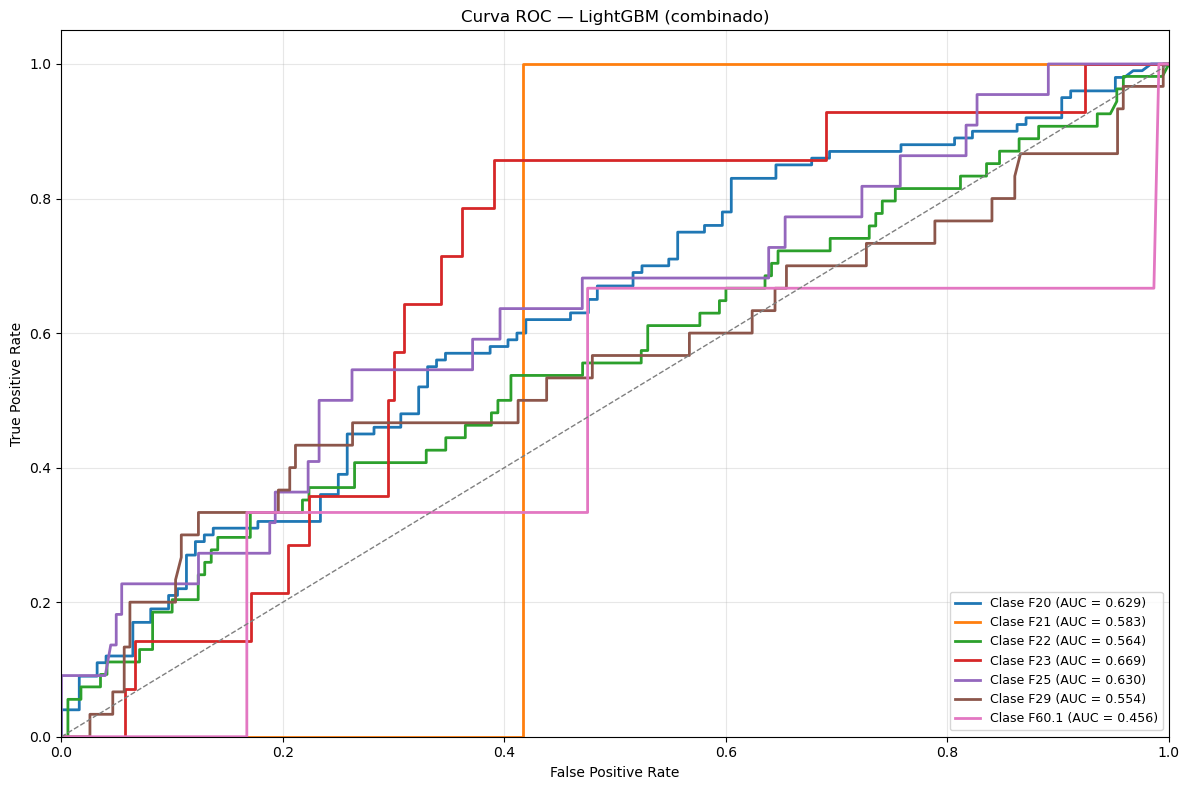

✅ Curva ROC guardada en: C:\Users\Usuario\Documents\Workspace\Mirage\TFG\results\LightGBM_combinado\roc_curve.png

AUC por clase:
  F20: 0.6289
  F21: 0.5830
  F22: 0.5636
  F23: 0.6690
  F25: 0.6297
  F29: 0.5538
  F60.1: 0.4563


In [26]:
# Celda 7 — Curva ROC multiclase (robusta)

print("\n📈 Generando curva ROC...")

y_pred_probs = model.predict_proba(X_test)
classes_model = np.asarray(model.classes_, dtype=int)

# Guardamos únicamente clases presentes en test y con probabilidad disponible.
present_test_classes = np.unique(y_test)
roc_data = {}

for class_id in present_test_classes:
    # ROC de una clase solo tiene sentido si hay positivos y negativos.
    y_binary = (y_test.to_numpy() == class_id).astype(int)
    if y_binary.sum() == 0 or y_binary.sum() == len(y_binary):
        continue

    model_col = np.where(classes_model == class_id)[0]
    if len(model_col) != 1:
        continue

    probs = y_pred_probs[:, model_col[0]]
    fpr, tpr, _ = roc_curve(y_binary, probs)
    class_auc = auc(fpr, tpr)
    roc_data[int(class_id)] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": float(class_auc),
    }

roc_plot_dir = os.path.join(results_dir, f"{model_type}_{dataset_type}")
os.makedirs(roc_plot_dir, exist_ok=True)
roc_plot_path = os.path.join(roc_plot_dir, "roc_curve.png")

if roc_data:
    plt.figure(figsize=(12, 8))

    for class_id, data in roc_data.items():
        plt.plot(
            data["fpr"],
            data["tpr"],
            lw=2,
            label=f"Clase {codes[class_id]} (AUC = {data['auc']:.3f})",
        )

    plt.plot([0, 1], [0, 1], linestyle="--", lw=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Curva ROC — {model_type} ({dataset_type})")
    plt.legend(loc="lower right", fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(roc_plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"✅ Curva ROC guardada en: {roc_plot_path}")

    print("\nAUC por clase:")
    for class_id, data in roc_data.items():
        print(f"  {codes[class_id]}: {data['auc']:.4f}")
else:
    print("⚠️ No se pudo calcular una curva ROC válida para las clases presentes en test.")


In [27]:
# Celda 8 — Guardar modelo, configuración y features

save_path = os.path.join(models_dir, f"{model_type}_{dataset_type}_final")
os.makedirs(save_path, exist_ok=True)

model_file_path = os.path.join(save_path, "model.joblib")
results_file_path = os.path.join(save_path, "training_results.json")
features_file_path = os.path.join(save_path, "feature_columns.json")

# Guardar solamente el modelo LightGBM.
joblib.dump(model, model_file_path)

resultado_final = {
    "modelo": model_type,
    "dataset": dataset_type,
    "features_shape": list(X_train.shape),
    "num_features": len(feature_cols),
    "num_classes": num_classes,
    "classes": codes,
    "feature_columns_file": "feature_columns.json",
    "metrics": metrics,
    "seed": seed,
    "lightgbm_params": model_params,
}

with open(results_file_path, "w", encoding="utf-8") as f:
    json.dump(resultado_final, f, indent=2, ensure_ascii=False)

with open(features_file_path, "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, indent=2, ensure_ascii=False)

print("\n💾 Guardado completado:")
print(f"  Modelo:      {model_file_path}")
print(f"  Resultados:  {results_file_path}")
print(f"  Features:    {features_file_path}")

print("\n🎯 RESUMEN FINAL")
print(f"Modelo:    {model_type}")
print(f"Dataset:   {dataset_type}")
print(f"F1-Score:  {metrics['f1']:.4f}")
print(f"Accuracy:  {metrics['accuracy']:.4f}")



💾 Guardado completado:
  Modelo:      C:\Users\Usuario\Documents\Workspace\Mirage\TFG\models\LightGBM_combinado_final\model.joblib
  Resultados:  C:\Users\Usuario\Documents\Workspace\Mirage\TFG\models\LightGBM_combinado_final\training_results.json
  Features:    C:\Users\Usuario\Documents\Workspace\Mirage\TFG\models\LightGBM_combinado_final\feature_columns.json

🎯 RESUMEN FINAL
Modelo:    LightGBM
Dataset:   combinado
F1-Score:  0.3821
Accuracy:  0.4554
